<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/titanic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("brendan45774/test-file")

Using Colab cache for faster access to the 'test-file' dataset.


In [2]:
import pandas as pd

# Assuming the downloaded file is a CSV, adjust if it's another format
# and that there is only one file in the directory.
import os
file_name = os.listdir(path)[0] if os.path.isdir(path) else path
df = pd.read_csv(os.path.join(path, file_name))
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [3]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
23,915,0,1,"Williams, Mr. Richard Norris II",male,21.0,0,1,PC 17597,61.3792,NaN,C
56,948,0,3,"Cor, Mr. Bartol",male,35.0,0,0,349230,7.8958,NaN,S
392,1284,0,3,"Abbott, Master. Eugene Joseph",male,13.0,0,2,C.A. 2673,20.2500,NaN,S


## Exploratory Data Analysis (EDA)

In [4]:
# Display basic information about the DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None


In [5]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage (%)
Cabin,327,78.229665
Age,86,20.574163
Fare,1,0.239234


From the missing values summary, we can see that `Age`, `Fare`, and `Cabin` columns have missing values. `Cabin` has a very high percentage of missing values, which might make it difficult to use directly without significant imputation or feature engineering.

Let's also look at the unique values of categorical columns and check for any 'na' string representations that weren't caught by `isnull()`.

In [6]:
# Display unique values and their counts for object (categorical) columns
for column in df.select_dtypes(include='object').columns:
    print(f"\nUnique values in '{column}':")
    display(df[column].value_counts(dropna=False))



Unique values in 'Name':


,count
Name,
"Peter, Master. Michael J",1
"Kelly, Mr. James",1
"Gale, Mr. Harry",1
"Bonnell, Miss. Caroline",1
"Conlon, Mr. Thomas Henry",1
...,...
"Connolly, Miss. Kate",1
"Svensson, Mr. Johan Cervin",1
"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1



Unique values in 'Sex':


,count
Sex,
male,266
female,152



Unique values in 'Ticket':


,count
Ticket,
PC 17608,5
CA. 2343,4
113503,4
347077,3
SOTON/O.Q. 3101315,3
...,...
330972,1
7538,1
3101298,1



Unique values in 'Cabin':


,count
Cabin,
NaN,327
B57 B59 B63 B66,3
B45,2
C23 C25 C27,2
C78,2
...,...
B41,1
C7,1
D40,1



Unique values in 'Embarked':


,count
Embarked,
S,270
C,102
Q,46


In [7]:
# Display summary statistics for numerical columns
display(df.describe())

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## Handling Missing Values

In [8]:
# Drop the 'Cabin' column due to a high number of missing values
df_processed = df.drop('Cabin', axis=1)
print("Dropped 'Cabin' column.")

# Impute missing 'Age' values with the median
df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
print("Imputed missing 'Age' values with the median.")

# Impute missing 'Fare' values with the median
df_processed['Fare'].fillna(df_processed['Fare'].median(), inplace=True)
print("Imputed missing 'Fare' values with the median.")

# Verify that there are no more missing values in the processed DataFrame
print("\nMissing values after imputation:")
missing_values_after = df_processed.isnull().sum()
display(missing_values_after[missing_values_after > 0])

df = df_processed.copy()

Dropped 'Cabin' column.
Imputed missing 'Age' values with the median.
Imputed missing 'Fare' values with the median.

Missing values after imputation:


/tmp/ipykernel_40787/1758311173.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed['Age'].fillna(df_processed['Age'].median(), inplace=True)
/tmp/ipykernel_40787/1758311173.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

,0


## Feature Engineering

In [28]:
import re

# Check if 'Name' column exists before extracting title
if 'Name' in df_processed.columns:
    # Extract Title from Name
    df_processed['Title'] = df_processed['Name'].apply(lambda name: re.search(' ([A-Za-z]+)\.', name).group(1) if re.search(' ([A-Za-z]+)\.', name) else '')

    # Consolidate specific titles first
    df_processed['Title'] = df_processed['Title'].replace('Mlle', 'Miss')
    df_processed['Title'] = df_processed['Title'].replace('Ms', 'Miss')
    df_processed['Title'] = df_processed['Title'].replace('Mme', 'Mrs')

    # Consolidate other rare titles
    df_processed['Title'] = df_processed['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')

    print("Title feature created:")
    display(df_processed['Title'].value_counts())
else:
    print("Skipping Title feature creation: 'Name' column not found (likely already processed).")

# Check if 'SibSp' and 'Parch' columns exist before creating FamilySize and IsAlone
if 'SibSp' in df_processed.columns and 'Parch' in df_processed.columns:
    # Create FamilySize feature
    df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1
    print("\nFamilySize feature created.")

    # Create IsAlone feature
    df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)
    print("IsAlone feature created.")
else:
    print("Skipping FamilySize and IsAlone feature creation: 'SibSp' or 'Parch' columns not found (likely already processed).")

# Display the head of the DataFrame with new features
print("\nDataFrame head after potential feature engineering:")
display(df_processed.head())

# Update the main df to reflect changes
df = df_processed.copy()

Skipping Title feature creation: 'Name' column not found (likely already processed).
Skipping FamilySize and IsAlone feature creation: 'SibSp' or 'Parch' columns not found (likely already processed).

DataFrame head after potential feature engineering:


<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_40787/4188562921.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_processed['Title'] = df_processed['Name'].apply(lambda name: re.search(' ([A-Za-z]+)\.', name).group(1) if re.search(' ([A-Za-z]+)\.', name) else '')
/tmp/ipykernel_40787/4188562921.py:6: SyntaxWarning: invalid escape sequence '\.'
  df_processed['Title'] = df_processed['Name'].apply(lambda name: re.search(' ([A-Za-z]+)\.', name).group(1) if re.search(' ([A-Za-z]+)\.', name) else '')


,PassengerId,Survived,Age,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,892,0,34.5,7.8292,1,1,True,True,False,False,True,False,True,False,False
1,893,1,47.0,7.0000,2,0,False,False,True,False,True,False,False,True,False
2,894,0,62.0,9.6875,1,1,True,True,False,True,False,False,True,False,False
3,895,0,27.0,8.6625,1,1,True,False,True,False,True,False,True,False,False
4,896,1,22.0,12.2875,3,0,False,False,True,False,True,False,False,True,False


## Categorical Feature Encoding

In [29]:
# Identify categorical columns for one-hot encoding
# These columns appear to have been already one-hot encoded and removed from the DataFrame.
# categorical_cols = ['Sex', 'Embarked', 'Pclass', 'Title'] # This line is kept for context, but not used for get_dummies.

# The one-hot encoding step has likely been performed already.
print("Categorical features (Sex, Embarked, Pclass, Title) appear to have been already processed/one-hot encoded.")

# Drop original columns that are no longer needed or have been transformed
drop_cols_to_check = ['Name', 'Ticket', 'SibSp', 'Parch', 'Sex', 'Embarked', 'Pclass', 'Title']
# Filter drop_cols_to_check to only include columns that actually exist in the DataFrame
existing_drop_cols = [col for col in drop_cols_to_check if col in df_processed.columns]

if existing_drop_cols:
    df_processed = df_processed.drop(existing_drop_cols, axis=1)
    print(f"Dropped columns: {', '.join(existing_drop_cols)}.")
else:
    print("No additional columns from the specified list ('Name', 'Ticket', 'SibSp', 'Parch', 'Sex', 'Embarked', 'Pclass', 'Title') needed to be dropped as they do not exist.")

# Display the first few rows of the processed DataFrame
print("\nDataFrame head after potential dropping of columns:")
display(df_processed.head())

# Display the new column names and shape to show the effect of encoding
print("\nShape of DataFrame after operations:", df_processed.shape)
print("New columns:", df_processed.columns.tolist())

# Update the main df to reflect changes
df = df_processed.copy()

Categorical features (Sex, Embarked, Pclass, Title) appear to have been already processed/one-hot encoded.
No additional columns from the specified list ('Name', 'Ticket', 'SibSp', 'Parch', 'Sex', 'Embarked', 'Pclass', 'Title') needed to be dropped as they do not exist.

DataFrame head after potential dropping of columns:


,PassengerId,Survived,Age,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,892,0,34.5,7.8292,1,1,True,True,False,False,True,False,True,False,False
1,893,1,47.0,7.0000,2,0,False,False,True,False,True,False,False,True,False
2,894,0,62.0,9.6875,1,1,True,True,False,True,False,False,True,False,False
3,895,0,27.0,8.6625,1,1,True,False,True,False,True,False,True,False,False
4,896,1,22.0,12.2875,3,0,False,False,True,False,True,False,False,True,False



Shape of DataFrame after operations: (418, 15)
New columns: ['PassengerId', 'Survived', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Pclass_2', 'Pclass_3', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']


In [30]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,Normalizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,r2_score,roc_curve,roc_auc_score,recall_score,precision_score,f1_score
from sklearn.pipeline import Pipeline

In [31]:
df.sample(3)

,PassengerId,Survived,Age,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S,Pclass_2,Pclass_3,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
374,1266,1,54.0,81.8583,3,0,False,False,True,False,False,False,False,True,False
396,1288,0,24.0,7.2500,1,1,True,True,False,False,True,False,True,False,False
327,1219,0,46.0,79.2000,1,1,True,False,False,False,False,False,True,False,False


# perfroming the test_train_split process dividing data in to   the testing and training

In [32]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Survived', axis=1), df['Survived'], test_size=0.2, random_state=42)

# making the pipeline

In [33]:
pipe=Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('normalizer',Normalizer()),
    ('model', LogisticRegression(solver='liblinear'))
])

## Model Training and Evaluation


1.   Accuracy
2.   Report
3.   Classification metric





In [34]:
# Fit the pipeline to the training data
pipe.fit(x_train, y_train)
print("Model training complete.")

# Make predictions on the test set
y_pred = pipe.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix,
                     index=['Actual Not Survived', 'Actual Survived'],
                     columns=['Predicted Not Survived', 'Predicted Survived']))

Model training complete.

Accuracy: 0.9881

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.99        34

    accuracy                           0.99        84
   macro avg       0.99      0.99      0.99        84
weighted avg       0.99      0.99      0.99        84


Confusion Matrix:


,Predicted Not Survived,Predicted Survived
Actual Not Survived,50,0
Actual Survived,1,33


In [35]:
accuracy=accuracy_score(y_test, y_pred)
accuracy

0.9880952380952381

# Showing the best fit line through the graphical representation

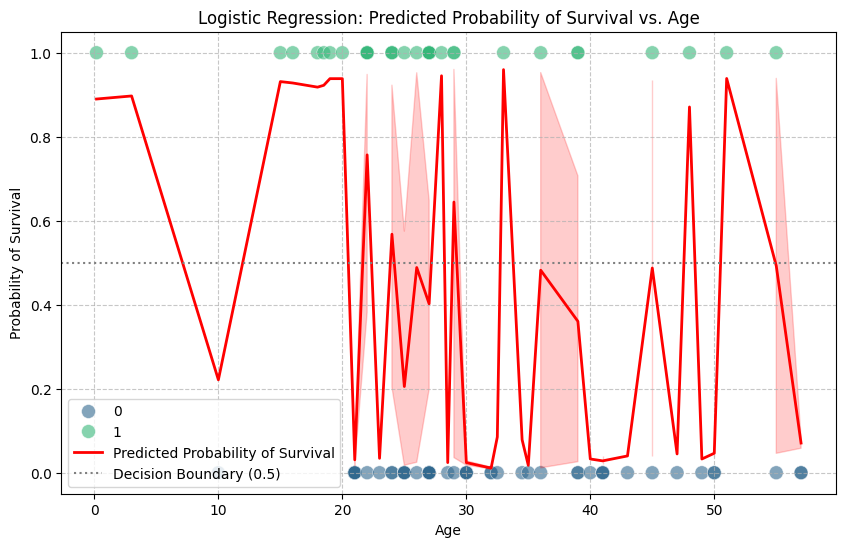

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get the 'Age' column from x_test and sort it to plot a smooth curve
age_data = x_test['Age'].copy().to_frame()

# Predict probabilities for the sorted age data
# We need to transform age_data using the pipeline steps before prediction
# However, pipe.predict_proba expects the full x_test structure.
# Let's create a temporary DataFrame for plotting the curve

# First, let's create a dataframe to visualize the probabilities
plot_df = x_test.copy()
plot_df['Predicted_Proba_Survived'] = pipe.predict_proba(x_test)[:, 1]
plot_df['Actual_Survived'] = y_test

# Sort by Age for a smoother curve representation
plot_df_sorted = plot_df.sort_values(by='Age')

plt.figure(figsize=(10, 6))

# Plot actual survival outcomes (jittered for better visibility)
sns.scatterplot(
    x='Age',
    y='Actual_Survived',
    data=plot_df_sorted,
    hue='Actual_Survived',
    palette='viridis',
    marker='o',
    s=100,
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5,
    legend=True
)

# Plot the predicted probability curve
sns.lineplot(
    x='Age',
    y='Predicted_Proba_Survived',
    data=plot_df_sorted,
    color='red',
    linewidth=2,
    label='Predicted Probability of Survival'
)

plt.title('Logistic Regression: Predicted Probability of Survival vs. Age')
plt.xlabel('Age')
plt.ylabel('Probability of Survival')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axhline(0.5, color='gray', linestyle=':', label='Decision Boundary (0.5)')
plt.legend()
plt.show()

## ROC Curve Analysis
here the  values of the auc is 1 so it means the modal is best classifier for the required data and it is correctly distinguish between the postive and the neg calsses with 100 accuracy.



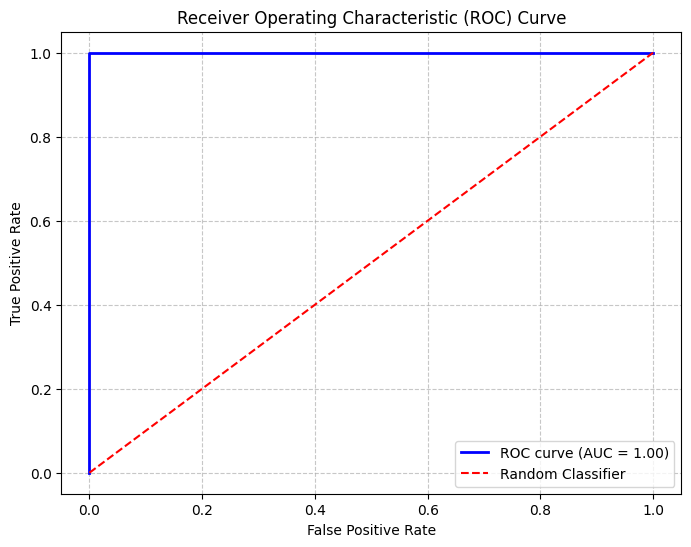

The Area Under the Curve (AUC) is: 1.00


In [37]:
# Get predicted probabilities for the positive class (survival)
y_pred_proba = pipe.predict_proba(x_test)[:, 1]

# Calculate ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f"The Area Under the Curve (AUC) is: {roc_auc:.2f}")

## Feature Importance Analysis

Top 10 Most Important Features:


,Feature,Importance,Absolute_Importance
5,Sex_male,-4.570483,4.570483
10,Title_Miss,2.924435,2.924435
11,Title_Mr,-2.699187,2.699187
12,Title_Mrs,2.644881,2.644881
2,Fare,0.426373,0.426373
6,Embarked_Q,0.407410,0.407410
1,Age,0.403719,0.403719
13,Title_Rare,-0.366887,0.366887
9,Pclass_3,-0.193504,0.193504
3,FamilySize,-0.123302,0.123302


/tmp/ipykernel_40787/2949357326.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')


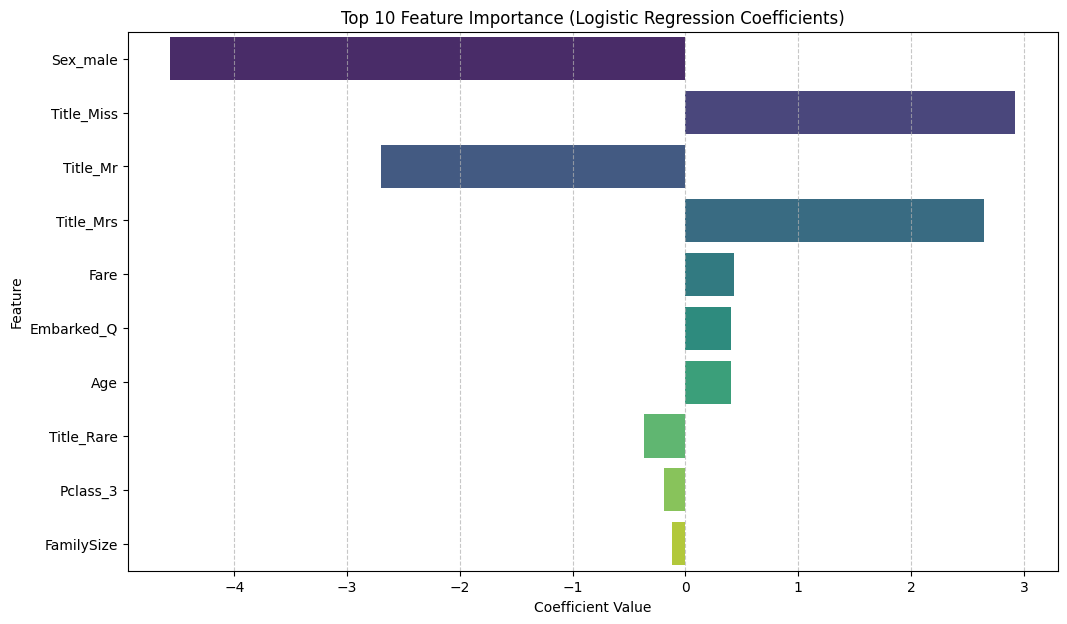

In [38]:
# Get the Logistic Regression model from the pipeline
logistic_model = pipe.named_steps['model']

# Get the feature names from x_train
feature_names = x_train.columns

# Get the coefficients from the logistic regression model
# For LogisticRegression, coef_ is a 2D array if multi_class is 'ovr' or 'multinomial'.
# For binary classification, it's usually (1, n_features), so we take the first row.
coefficients = logistic_model.coef_[0]

# Create a DataFrame to store feature importance
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})

# Sort by absolute importance (magnitude of coefficient)
feature_importance['Absolute_Importance'] = np.abs(feature_importance['Importance'])
feature_importance = feature_importance.sort_values(by='Absolute_Importance', ascending=False)

print("Top 10 Most Important Features:")
display(feature_importance.head(10))

# Visualize feature importance
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()